# Restaurant & Café Sales Trend Analysis
## Phase 2 — Exploratory Data Analysis (EDA)

**Author:** Carl Mark Sibal 

**Tools:** Python, Pandas, Matplotlib, Seaborn

**Dataset Sources:** Balaji Fast Food Sales (India) & Dirty Café Sales (Canada) (both from kaggle)


---

## Project Overview
This project analyzes sales data **(synthetic)** from two food businesses — a Canadian café and an Indian fast food restaurant — using synthetic data sourced from Kaggle. The goal is to uncover revenue trends, top-performing items, and seasonal patterns, and to develop data-driven recommendations for sales and marketing improvement across seasons.


The analysis spans 4 phases:
- **Phase 1** — Data Cleaning 
- **Phase 2** — Exploratory Data Analysis <<--
- **Phase 3** — Combined Analysis & Weather API Integration 
- **Phase 4** — Power BI Dashboard 
## Phase Overview

In this phase of the project, the datasets will be explored further and relationships between existing variables will be analyzed. New information that we uncover will also be investigated. 

--------------------------------------------------



In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.patches as patches

In [3]:
# The names have been changed back to df1 and df2 for easier calling
df2 = pd.read_csv(r"C:\Users\rougs\Desktop\data cleaning project\cafeclean.csv")
df1 = pd.read_csv(r"C:\Users\rougs\Desktop\data cleaning project\fastfoodclean.csv")

In [4]:
# converting date to datetime cuz somehow it reverted after getting saved as csv
df1['date'] = pd.to_datetime(df1['date'], format='mixed')
df2['date'] = pd.to_datetime(df2['date'], format='mixed')

Since we already cleaned earlier and checked for duplicates and missing values and dealt with them, we can move straight to checking the features. 

## Monthly sum of the 2 dataset

--------------------------------

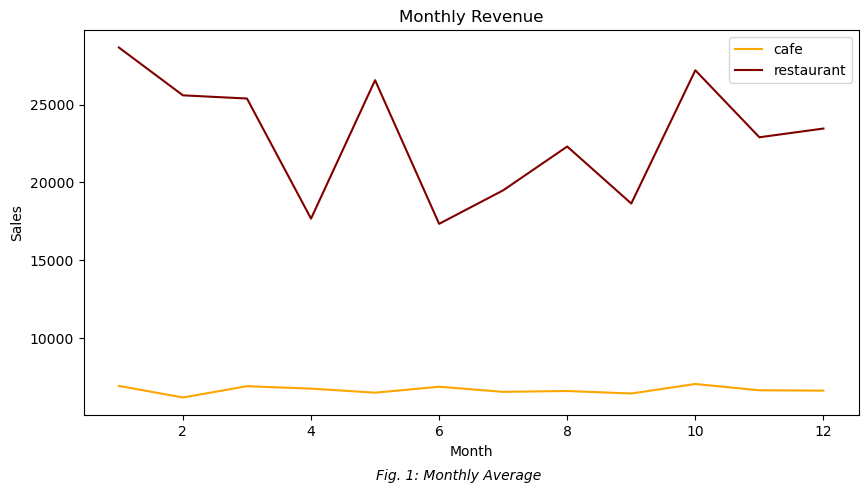

In [5]:

# Monthly average
mA2 = df2.groupby(df2['date'].dt.month)['Total_spent'].sum() # cafe
mA1 = df1.groupby(df1['date'].dt.month)['transaction_amount'].sum() # restaurant

# plot for both
fig = plt.figure(figsize=(10, 5))
plt.plot(mA2.index, mA2.values, label ='cafe', color ='orange')
plt.plot(mA1.index, mA1.values, label = 'restaurant', color='maroon')
plt.title('Monthly Revenue')
plt.xlabel('Month',)
plt.ylabel('Sales')
fig.text(0.5, -0.02, 'Fig. 1: Monthly Average', 
         ha='center', fontsize=10, style='italic')
plt.legend()
plt.show()


## Adjustment:
After looking at the graph, I realize the Balaji Fast Food dataset uses Indian Rupees(INR)—which explains the gap— while the Café datasetuses Canadian Dollars(CAD). Direct monetary comparison would be misleading, so both datasetswill be analyzed independently.Trend comparisonsonly where applicable.Subplots will be used instead of joining them.


### Subplots

To fix the problem from the previous chart we divide them into 2 subplots and analyze them both individually. 

--------------------------------

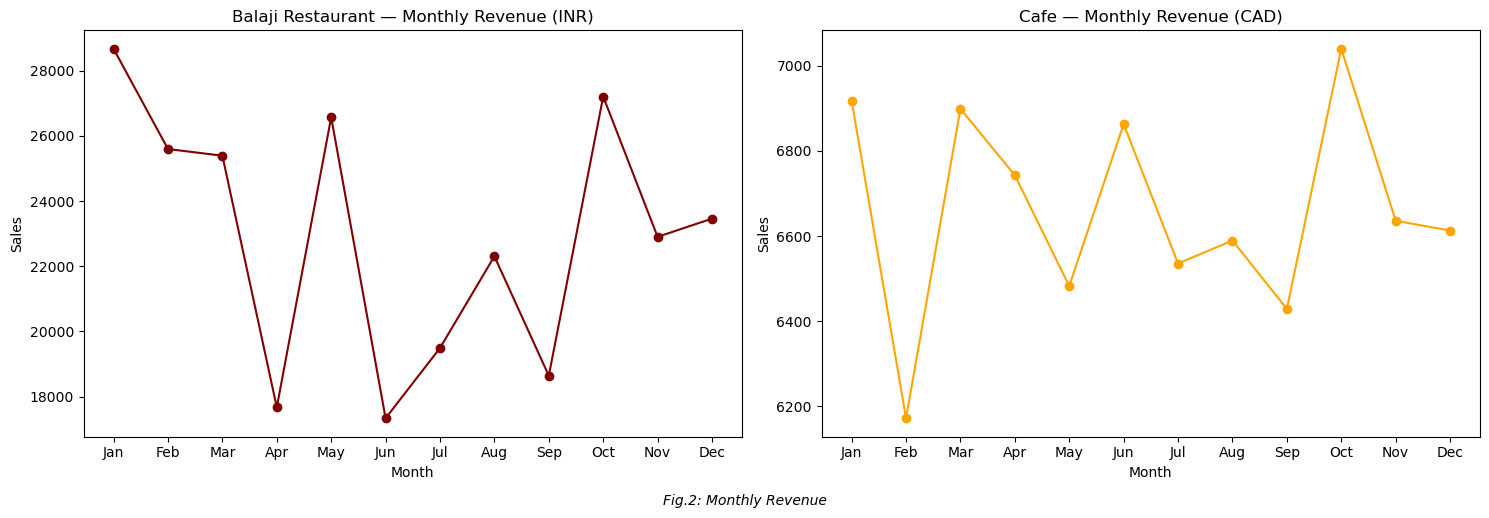

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.text(0.5, -0.02, 'Fig.2: Monthly Revenue', 
         ha='center', fontsize=10, style='italic')
# right chart - Cafesales

axes[1].plot(mA2.index,mA2.values, marker = 'o', color= 'orange')
axes[1].set_title('Cafe — Monthly Revenue (CAD)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales')
axes[1].set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

# left chart - Restaurant sales
axes[0].plot(mA1.index,mA1.values, marker = 'o', color ='maroon' )
axes[0].set_title('Balaji Restaurant — Monthly Revenue (INR)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Sales')
axes[0].set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

## Monthly Revenue
--------------------
Both businesses generate consistent monthly revenue within their respective regions. Both experience a similar dip around Q3— potentially driven by summer downtime in Canada and monsoon season in India. This will be further explored in Phase 3 where the correlation between sales and weather will be explored along with other metrics that might be directly affecting sales. 

To further increase the revenue of both the restaurants we can suggest different methods like increasing order value, or bundling items in a deal. **However as shown below**, the data provided does not support any of these since the rows in both the datasets only consists of one unique item per transaction and lacks the natural variance that would allow a proper basket analysis. 

However, different suggestions for the stores' performance improvement can still be made after uncovering more revenue driving factors and how they affect sales. 

In [7]:
multi_item_rows = df1.groupby('order_id').filter(
    lambda x: x['item_name'].nunique() > 1
)

print('Number of unique items per transaction per row:',len(multi_item_rows))

Number of unique items per transaction per row: 0


## Revenue per item (Yearly total)
--------------------------------------
Here we can see how each items are performing after the year concludes.



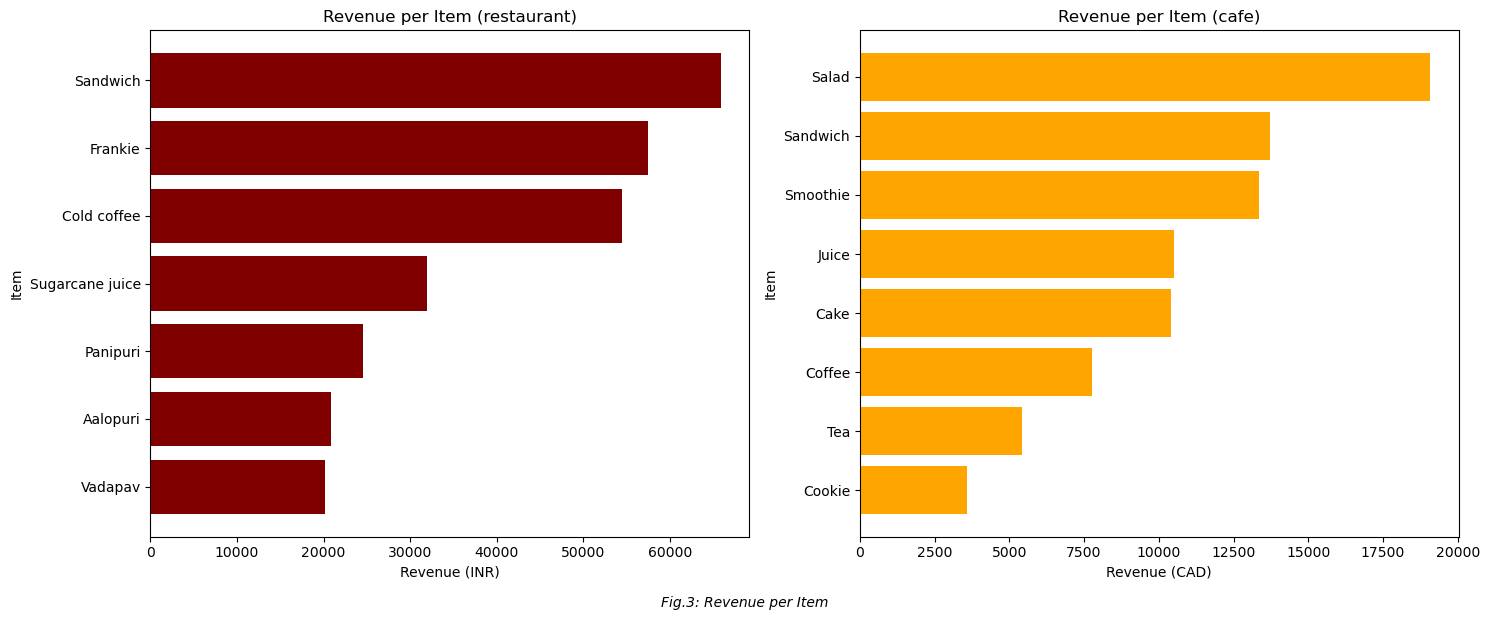

In [8]:
# Aggregating
item_revenue_cafe = df2.groupby('Item')['Total_spent'].sum()
item_revenue_restaurant = df1.groupby('item_name')['transaction_amount'].sum()

#values
cTotal_revenue = item_revenue_cafe.sort_values(ascending = True).head(10)
rTotal_revenue = item_revenue_restaurant.sort_values(ascending = True).head(10)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.text(0.5, -0.02, 'Fig.3: Revenue per Item', 
         ha='center', fontsize=10, style='italic')


# Restaurant
axes[0].barh(rTotal_revenue.index,rTotal_revenue.values, color ='maroon')
axes[0].set_title('Revenue per Item (restaurant)')
axes[0].set_xlabel('Revenue (INR)')
axes[0].set_ylabel('Item')

# Cafe
axes[1].barh(cTotal_revenue.index,cTotal_revenue.values, color ='orange')
axes[1].set_title('Revenue per Item (cafe)')
axes[1].set_xlabel('Revenue (CAD)')
axes[1].set_ylabel('Item')


plt.tight_layout()
plt.show()

----------------------------------------------
After looking at the revenue chart and looking at the top performing items in the menu, we can see that there are items are not doing so great as the others like cookie, tea, Aalopuri and Vadapav. At first glance, one might think that this is simply because of the item's popularity but a deeper look would tell a different story.

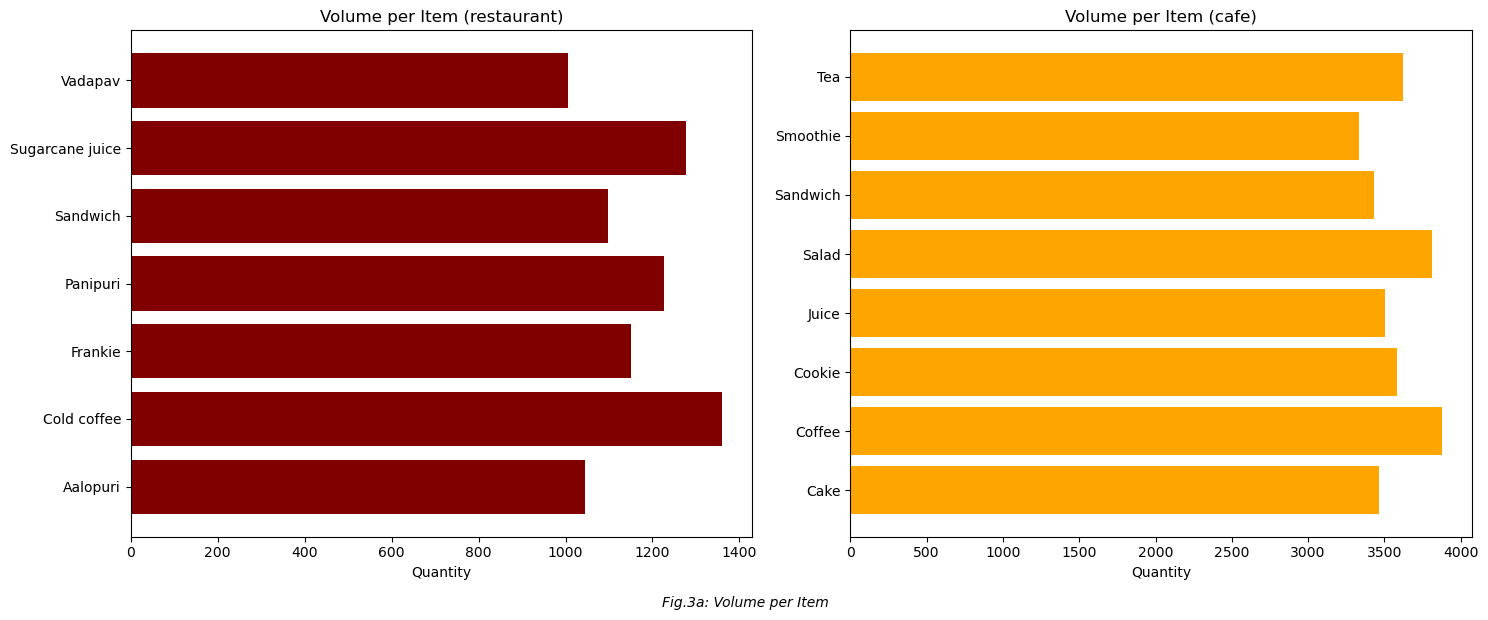

In [22]:
# Values for the volume chart

C1 = df1.groupby(df1['item_name'])['quantity'].sum()
C2 = df2.groupby(df2['Item'])['Quantity'].sum()

#The chart
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.text(0.5, -0.02, 'Fig.3a: Volume per Item', 
         ha='center', fontsize=10, style='italic')
# Cafe
axes[0].barh(C1.index,C1.values, color = 'maroon')
axes[0].set_title('Volume per Item (restaurant)')
axes[0].set_xlabel('Quantity')

# Restaurant
axes[1].barh(C2.index,C2.values, color ='orange')
axes[1].set_title('Volume per Item (cafe)')
axes[1].set_xlabel('Quantity')


plt.tight_layout()
plt.show()


---------------------------
After a closer look at the volume per item charts, we get **an almost even volume distribution across all items in both datasets** which suggests that the popularity of the items is not the main driver of revenue in both datasets. Rather it is the **price itself that drives revenue of each item** . Here, we can start drawing conclusions about how to improve sales of both restaurants. However as discussed earlier, basket analysis is out of the options since all of the transactions across the two datasets contain only one item each.

But before we explore further any recommendations for sales improvement, let's take a look at the quarterly sales and see if it tells another story. 

**<span style="color: maroon;">Restaurant</span>**

Looking at the graph above ***(Fig.2:Monthly Revenue)*** , we observe that there are three points in time during this year where revenue spiked: **January, May, and October**. These spikes in revenue can be tied to several events such as religious festivities, general weather and/or holidays. For simplicity's sake, we will treat holidays and festivities as one entity and will be analyzed as one.


## Quarterly Sales
-----------------------------------------------
We take a look at the quarterly sales reveal seasonal trends and possibly find more correlations between different factors that drive revenue.

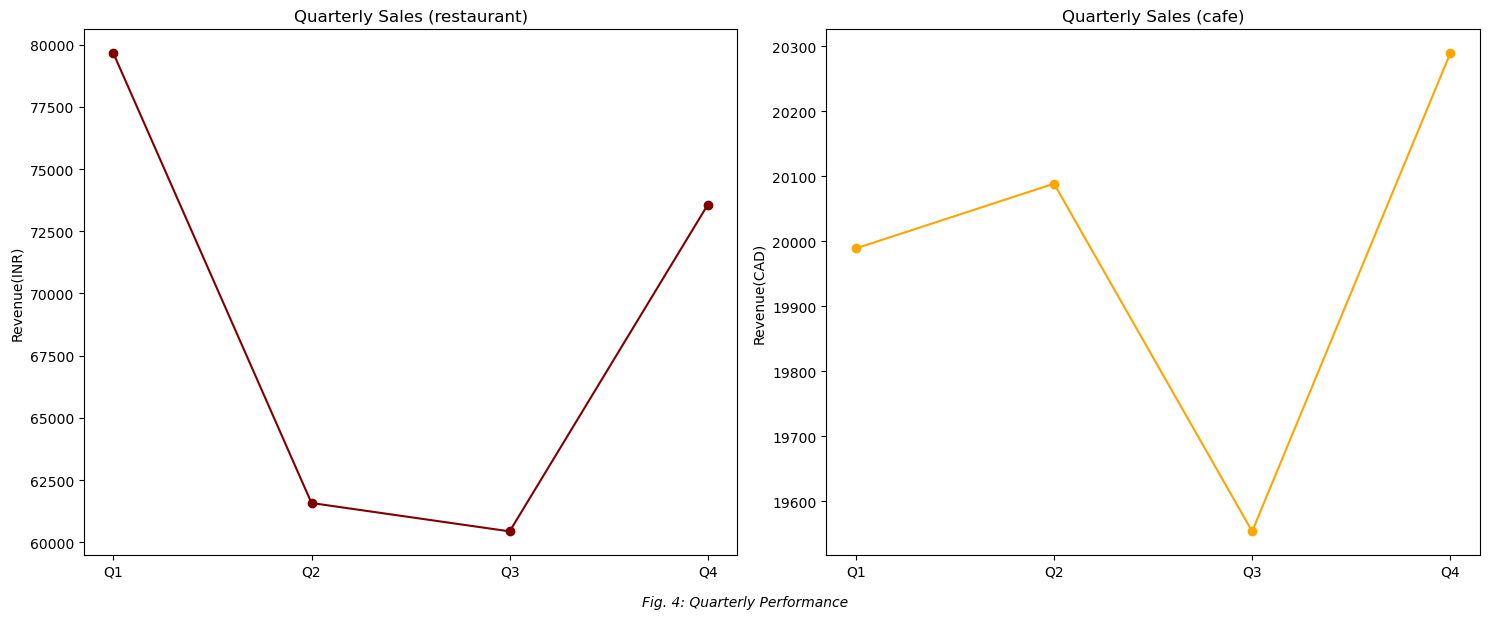

In [10]:
df1Q = df1.groupby(df1['date'].dt.quarter)['transaction_amount'].sum()
df2Q = df2.groupby(df2['date'].dt.quarter)['Total_spent'].sum()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
fig.text(0.5, -0.02, 'Fig. 4: Quarterly Performance', 
         ha='center', fontsize=10, style='italic')

# Cafe
axes[0].plot(df1Q.index,df1Q.values, marker = 'o', color = 'maroon')
axes[0].set_title('Quarterly Sales (restaurant)')
axes[0].set_ylabel('Revenue(INR)')
axes[0].set_xticks([1,2,3,4])
axes[0].set_xticklabels(['Q1','Q2','Q3','Q4'])

# Restaurant
axes[1].plot(df2Q.index,df2Q.values, marker = 'o', color ='orange')
axes[1].set_title('Quarterly Sales (cafe)')
axes[1].set_ylabel('Revenue(CAD)')
axes[1].set_xticks([1,2,3,4])
axes[1].set_xticklabels(['Q1','Q2','Q3','Q4'])

plt.tight_layout()
plt.show()


**Both the stores share a similar trend that spikes at the Q4**. These spikes might be brought by factors such as highly seasonal items such as coffee and tea for the cafe, and cold coffee for the restaurant. 

For **Q4 <span style="color: orange;">(cafe)</span>** the spike is so much higher compared to **Q4 <span style="color: maroon;">(restaurant)</span>** which is hypothesized to be brought by the extreme cold weather up in Canada compared to the extremely mild winter in India. The Canadian winter drives customers indoors and increases demand for hot beverages, resulting in a more protruding and sustained sales peak. While the Indian market experiences a comparatively modest spike, likely driven more by the festivities spending (Diwali, Christmas) rather than weather-driven demands.

Both stores converge again by **Q2 and Q3**, where rising temperatures reduce foot traffic, particularly around the physical vicinity of both stores. This suggests that **weather remains the dominant external factor** directly driving sales patterns across both markets, despite their geographical and cultural differences.

Additionally, **cultural festivities** such as Diwali and New Year celebrations in India may independently drive Q4 revenue for the **<span style="color: maroon;">(restaurant)</span>**, separate from any weather effect. Isolating these two factors through further analysis would help determine whether the Q4 bump is **weather-driven, festivity-driven, or a combination of both.**



## Insight - Quarterly and Monthly Performance
-----------------------------
After careful analysis of the monthly and quarterly revenue, it becomes apparent that **weather alone may not be the only factor driving revenue.** Monthly breakdown **(Fig.2)** reveals that the **<span style="color: maroon;">restaurant</span>** spike begins as early as **October**, aligning closely with the beginning of the **Diwali festive period** which solely spiked up the store's performance in **(Fig.4: Q4)** suggesting that **cultural festivities drive foot traffic and in turn revenue** for the Indian market and potentially the Canadian market given its multicultural demographic

As for the **<span style="color: orange;">cafe</span>**, we see from the monthly sales in **(Fig.2)** that there is a sudden spike in May it is not clear as of now what causes this which is why further analysis of the individual item performance will be explored to gain more insights about it

This expands the analysis beyond weather and introduces **festivities as an additional factor**which will be explored in **Phase 3**. Individual item performance will also be analyzed alongside weather and festivity data to uncover more **concrete, localized business recommendations** for each store.



# Phase 2 — Summary & Closing Remarks

-----------------------------------------------------

## Key observations:
Through exploratory data analysis we uncovered the following key findings across both businesses:

- **Revenue is price-driven, not demand-driven** — item quantities are roughly equal across all menu items in both stores, meaning price point is the primary differentiator in revenue performance.

- **Both businesses share a mid-year dip (Q2-Q3)** — suggesting  external factors such as weather or seasonality may be influencing customer behaviour regardless of geography.

- **Cultural festivities matter** — the restaurant's Q4 spike aligns closely with the Diwali period, suggesting foot traffic is culturally driven in the Indian market and possibly in the Canadian market due to its multicultural demograpj.

## Up next

--------------------------------------
Phase 3 will enrich this analysis by integrating external data sources — specifically weather data via the Open-Meteo API and festivity calendars linked to increased activities around the area — to validate these hypotheses and **produce concrete, localized business recommendations for each store.**


